# 14.2.2 模态、采样与预测范围

## 学习目标与先修知识

从离散特征值（eigenvalue）解释衰减与角频率，识别采样（sampling）混叠（aliasing）和局部拟合的外推限制。

先修：14.2.1 配对快照；复数（complex number）模态（mode）、特征值与采样间隔。

## 具体问题

同一旋转衰减轨迹（trajectory）若只隔很长时间看一次，会得到唯一的连续振荡频率吗？局部线性算子的特征值能否解释远离训练范围的非线性轨迹？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style
plot_style()
font_names={font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei","SimHei","Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"]=[name,"DejaVu Sans"]
        break
BLUE,PINK,GREEN="#008bfb","#ff0051","#00a56a"

## 初步实验

对一个离散复特征值直接计算模与主值相角，观察它们怎样随采样间隔转成连续时间数值。

In [2]:
value=.92*np.exp(.5j);print('离散特征值：',value);print('衰减率与主值角频率：',[np.log(abs(value))/.4,np.angle(value)/.4])

离散特征值： (0.807375956939143+0.4410714955158668j)
衰减率与主值角频率： [np.float64(-0.20845402234762753), np.float64(1.2499999999999998)]


## 模型假设

采样间隔固定且正；离散传播矩阵（matrix）描述给定观测（observation）和训练范围。以下连续频率只采用复对数的主值分支，不把它当作无混叠的真实频率。远离训练初值（initial condition）的非线性对照另行评估。

## 数学解释与推导

对离散特征值 $\lambda=\rho e^{i\theta}$，$A\phi=\lambda\phi$；$\rho<1$ 表示该线性模态每步幅度收缩。采样间隔 $\Delta t$ 下，主值连续衰减率为 $\log\rho/\Delta t$，主值角频率为 $\theta/\Delta t$，其中 $\theta=\operatorname{atan2}(\Im\lambda,\Re\lambda)\in(-\pi,\pi]$。因为 $\theta+2\pi k$ 给出相同离散特征值，连续频率存在分支歧义，必须结合采样与先验（prior）范围。DMD 特征值只属于所拟合的算子；非线性系统的局部线性近似不能自动外推。

## 核心实现

以下是本节完整计算步骤，可逐行修改。

In [3]:
def dmd_fit(past, future, rank):
    """Fit Y X_r^+ with zero singular directions discarded."""
    x = np.asarray(past, dtype=float)
    y = np.asarray(future, dtype=float)
    left, singular, right_t = np.linalg.svd(x, full_matrices=False)
    keep = min(rank, len(singular))
    if keep == 0:
        return np.zeros((x.shape[0], x.shape[0])).tolist()
    cutoff = 1e-12 * singular[0]
    inverse = np.divide(1., singular[:keep],
                        out=np.zeros(keep), where=singular[:keep] > cutoff)
    operator = (y @ right_t[:keep].T * inverse) @ left[:, :keep].T
    return operator.tolist()


def linear_roll(operator, initial, steps):
    """Include the initial state, then repeatedly apply a fixed operator."""
    matrix = np.asarray(operator, dtype=float)
    state = np.asarray(initial, dtype=float)
    history = [state.tolist()]
    for _ in range(steps):
        state = matrix @ state
        history.append(state.tolist())
    return history


def dmd_rates(real, imag, dt):
    """Principal-branch rates of a nonzero discrete eigenvalue."""
    radius = float(np.hypot(real, imag))
    return [float(np.log(radius) / dt), float(np.arctan2(imag, real) / dt)]

## 对照实验

先在精确阻尼旋转上恢复特征值，再给同一传播增加幅度相关的非线性项，比较小幅训练与大幅留出轨迹。

特征值： [0.80737596+0.4410715j 0.80737596-0.4410715j]
主值速率： [[-0.20845402234762753, 1.2499999999999998], [-0.20845402234762753, -1.2499999999999998]]


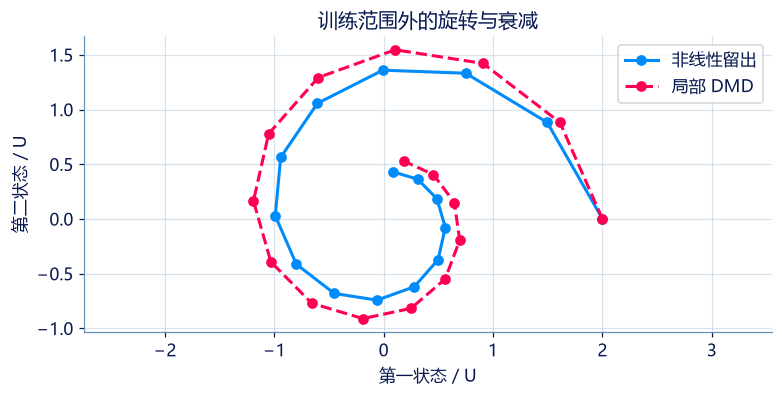

In [4]:
dt=.4;angle=.5;radius=.92
A=radius*np.array([[np.cos(angle),-np.sin(angle)],[np.sin(angle),np.cos(angle)]])
eigen=np.linalg.eigvals(A);print('特征值：',eigen);print('主值速率：',[dmd_rates(z.real,z.imag,dt) for z in eigen])
def nonlinear_step(x):
    return A@x-.015*np.linalg.norm(x)**2*x
state=np.array([.45,0.]);train=[state.copy()]
for _ in range(30):state=nonlinear_step(state);train.append(state.copy())
X=np.asarray(train[:-1]).T;Y=np.asarray(train[1:]).T;local=np.asarray(dmd_fit(X,Y,2))
state=np.array([2.,0.]);truth=[state.copy()]
for _ in range(15):state=nonlinear_step(state);truth.append(state.copy())
pred=np.asarray(linear_roll(local,[2.,0.],15));truth=np.asarray(truth)
fig,ax=plt.subplots(figsize=(7,3.5));ax.plot(truth[:,0],truth[:,1],'o-',label='非线性留出',color=BLUE);ax.plot(pred[:,0],pred[:,1],'o--',label='局部 DMD',color=PINK)
ax.set(xlabel='第一状态 / U',ylabel='第二状态 / U',title='训练范围外的旋转与衰减');ax.legend();ax.axis('equal');ax.grid(alpha=.25);plt.show()

## 结果解释

精确线性例的特征值确实揭示每步旋转与衰减；对幅度相关模型（model），小幅数据得到的线性算子无法保证大幅初值预测。图形偏离说明当前表示的适用范围，不单独证实某个替代机制。

### 独立核对

用代数值核对模、主值相角；将相角加整圈后检查离散特征值不变。

In [5]:
rate=dmd_rates(value.real,value.imag,.4)
np.testing.assert_allclose(rate,[np.log(.92)/.4,.5/.4],atol=1e-12)
np.testing.assert_allclose(np.exp(1j*(.5+2*np.pi)),np.exp(.5j),atol=1e-12)
assert np.linalg.norm(pred[-1]-truth[-1])>.01
print('特征值、分支与留出差异核验通过。')

特征值、分支与留出差异核验通过。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/14-02-%E5%8A%A8%E6%80%81%E6%A8%A1%E6%80%81%E5%88%86%E8%A7%A3/explore/)，再返回此处核对完整推导。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：从离散特征值读主值速率

给定非零复特征值（eigenvalue）的实部、虚部和采样（sampling）间隔，返回连续时间主值衰减率与主值角频率。

**函数与代码模板**

```python
def solve(
    real: float,
    imag: float,
    dt: float,
) -> list[float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `real` | `float` | 离散特征值的实部。 | 1 |
| `imag` | `float` | 离散特征值的虚部。 | 1 |
| `dt` | `float` | 正采样间隔。 | T |

**返回值**

直接返回 rates（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `rates` | `list[float]` | 依次为 log(&#124;λ&#124;)/dt 和 atan2(imag,real)/dt。 | 1/T |

**计算规则**

特征值非零，角度采用 atan2 的主值区间；不得以主值直接断言真实频率无混叠（aliasing）。

**约束与边界**

- dt>0，real²+imag²>0；全部输入（input）有限。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| real | 离散特征值的实部。 | 0 | 1 |
| imag | 离散特征值的虚部。 | 1 | 1 |
| dt | 正采样间隔。 | 0.5 | T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
real = 0.0
imag = 1.0
dt = 0.5

result = solve(real, imag, dt)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| rates | 依次为 log(|λ|)/dt 和 atan2(imag,real)/dt。 | [0.0, 3.141592653589793] | 1/T |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [0.0, 3.141592653589793]
```

**样例解释**

首例幅度不变而相角为 π/2，所以衰减率为0，主值角频率为 π/T；整圈混叠仍可能存在。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：从离散特征值读主值速率](http://127.0.0.1:8000/chapters/14-02-%E5%8A%A8%E6%80%81%E6%A8%A1%E6%80%81%E5%88%86%E8%A7%A3/practice/?question=p14-dmd-rates)

### 第 2 题 · 单项选择题：同一个离散旋转

离散特征值（eigenvalue）的相角为 0.5 rad。采样（sampling）间隔 Δt 已知，以下哪项正确？

- **A.** (0.5+2πk)/Δt 的频率可给出同一离散相角。
- **B.** 主值频率必是真实唯一频率。
- **C.** 相角与频率完全无关。
- **D.** 改用更大的 rank 就消除所有时间混叠（aliasing）。

[作答：同一个离散旋转](http://127.0.0.1:8000/chapters/14-02-%E5%8A%A8%E6%80%81%E6%A8%A1%E6%80%81%E5%88%86%E8%A7%A3/practice/?question=p14-angle-alias)

### 第 3 题 · 单项选择题：模态幅度的每步变化

线性传播的某离散模态（mode）特征值（eigenvalue）模为 0.8。只在该模态的线性解释内，可推出什么？

- **A.** 该模态幅度每步乘0.8。
- **B.** 原非线性系统所有状态（state）都以0.8 衰减。
- **C.** 连续衰减率就是0.8/T。
- **D.** 特征值必为实数。

[作答：模态幅度的每步变化](http://127.0.0.1:8000/chapters/14-02-%E5%8A%A8%E6%80%81%E6%A8%A1%E6%80%81%E5%88%86%E8%A7%A3/practice/?question=p14-eigen-modulus)

### 第 4 题 · 单项选择题：局部拟合的边界

小幅振荡训练得到的 DMD 在大幅留出初值（initial condition）上偏离。哪项解释最审慎？

- **A.** 线性拟合的适用范围可能不足，需独立条件验证。
- **B.** 一次偏离就证明真实系统混沌（chaos）。
- **C.** 只要一步残差（residual）小就忽略留出误差。
- **D.** 把留出轨迹（trajectory）加入训练再称原测试通过。

[作答：局部拟合的边界](http://127.0.0.1:8000/chapters/14-02-%E5%8A%A8%E6%80%81%E6%A8%A1%E6%80%81%E5%88%86%E8%A7%A3/practice/?question=p14-local-operator)

**进一步阅读**

[Tu 等人的 DMD 理论论文](https://doi.org/10.3934/jcd.2014.1.391)讨论配对快照与模态；本节连续时间转换明确只取主值分支。